# Курсовая работа

## Модель Лотки-Вольтерры

**Студент:** Сушков Степан Алексеевич  
**Курс:** 3  
**Группа:** ИВТ-5  
**Вариант:** 33

**Параметры варианта:**

| Параметр | Значение |
|---|---:|
| $\alpha$ | 0.489 |
| $\beta$ | 0.03762 |
| $\delta$ | 0.00675 |
| $\gamma$ | 0.27 |

**Начальные условия:**

| Опыт | Жертвы $x(0)$ | Хищники $y(0)$ |
|---:|---:|---:|
| 1 | 28 | 9 |
| 2 | 52 | 10 |
| 3 | 32 | 17 |
| 4 | 48 | 16 |

## Цель и задачи работы

**Цель работы** — изучить математическую модель популяционной динамики Лотки-Вольтерры, выполнить теоретический анализ, реализовать численный симулятор и сопоставить аналитические результаты с данными численного моделирования.

Для достижения цели необходимо решить следующие задачи:

1. Рассмотреть исторический контекст возникновения модели и области ее применения.
2. Записать систему дифференциальных уравнений Лотки-Вольтерры и объяснить смысл ее параметров.
3. Найти точки равновесия системы аналитически.
4. Выполнить классификацию стационарных точек с помощью матрицы Якоби.
5. Построить численный симулятор модели для параметров варианта 33.
6. Получить графики зависимости популяций от времени и фазовые траектории.
7. Сравнить теоретические и численные результаты.

## Введение

Модель Лотки-Вольтерры является одной из классических моделей математической биологии. Ее происхождение связано с работами А. Дж. Лотки и В. Вольтерры: книга Лотки была опубликована в 1925 г., а работа Вольтерры о колебаниях численности взаимодействующих видов была опубликована в 1920-е годы [1], [2].[^lotka][^volterra]

В современной форме эта модель описывает динамику двух популяций, одна из которых рассматривается как жертва, а другая как хищник [3], [4].[^scholarpedia][^wiki] Поэтому прямое применение модели относится к биологии и экологии: она показывает, как взаимное влияние видов может приводить к колебаниям численности. В электронном источнике Scholarpedia также отмечено, что близкие уравнения и идеи взаимодействующих популяций применяются не только в экологии, но и в других областях, включая экономические интерпретации [3].

Актуальность модели состоит в том, что она позволяет на простом примере изучить нелинейную динамику, равновесия, фазовые траектории и связь между аналитическими расчетами и численным экспериментом. Несмотря на упрощенные предположения, модель дает наглядное представление о том, как взаимодействие двух популяций может порождать регулярные колебания.

## 1. Теоретические основы модели

Обозначим через $x(t)$ численность популяции жертв, а через $y(t)$ численность популяции хищников в момент времени $t$. Классическая система Лотки-Вольтерры имеет вид [3], [4]:[^scholarpedia][^wiki]

$$
\begin{cases}
\dfrac{dx}{dt}=\alpha x-\beta xy,\\[4pt]
\dfrac{dy}{dt}=\delta xy-\gamma y.
\end{cases}
$$

Смысл параметров следующий [3], [4]:

- $\alpha>0$ — естественный коэффициент роста жертв при отсутствии хищников;
- $\beta>0$ — коэффициент убывания жертв из-за встреч с хищниками;
- $\delta>0$ — коэффициент прироста хищников за счет потребления жертв;
- $\gamma>0$ — естественный коэффициент убывания хищников при отсутствии жертв.

Слагаемое $\alpha x$ описывает размножение жертв без учета хищников. Слагаемое $-\beta xy$ описывает уменьшение численности жертв из-за встреч с хищниками. В уравнении для хищников слагаемое $\delta xy$ отвечает за рост популяции хищников при наличии пищи, а слагаемое $-\gamma y$ — за естественную смертность хищников.

Возможные режимы динамики удобно описывать через фазовую плоскость. Нулевая точка равновесия соответствует отсутствию обеих популяций и является седловой. Положительная точка равновесия соответствует сосуществованию жертв и хищников. Для классической модели вокруг нее возникают периодические колебания; это согласуется с описанием равновесий и колебаний в источниках [3], [4].

## 2. Аналитический поиск точек равновесия

Точки равновесия находятся из условий:

$$
\frac{dx}{dt}=0, \qquad \frac{dy}{dt}=0.
$$

Для системы Лотки-Вольтерры получаем:

$$
x(\alpha-\beta y)=0,
$$

$$
y(\delta x-\gamma)=0.
$$

Отсюда следуют две стационарные точки:

$$
E_0=(0,0),
$$

$$
E_* = \left(\frac{\gamma}{\delta},\frac{\alpha}{\beta}\right).
$$

Для варианта 33:

$$
x_* = \frac{0.27}{0.00675}=40,
$$

$$
y_* = \frac{0.489}{0.03762}\approx 12.9984.
$$

Следовательно, теоретическое внутреннее равновесие равно:

$$
E_*\approx(40; 12.9984).
$$

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root

alpha = 0.489
beta = 0.03762
delta = 0.00675
gamma = 0.27

initial_conditions = [
    (28, 9),
    (52, 10),
    (32, 17),
    (48, 16),
]

x_star = gamma / delta
y_star = alpha / beta
linear_period = 2 * math.pi / math.sqrt(alpha * gamma)

print(f"Точка равновесия E*: x* = {x_star:.6f}, y* = {y_star:.6f}")
print(f"Линеаризованная оценка периода около E*: T = {linear_period:.6f}")

Точка равновесия E*: x* = 40.000000, y* = 12.998405
Линеаризованная оценка периода около E*: T = 17.291934


## 3. Классификация равновесий

Для классификации равновесий используем матрицу Якоби:

$$
J(x,y)=
\begin{pmatrix}
\alpha-\beta y & -\beta x\\
\delta y & \delta x-\gamma
\end{pmatrix}.
$$

В точке $E_0=(0,0)$:

$$
J(0,0)=
\begin{pmatrix}
\alpha & 0\\
0 & -\gamma
\end{pmatrix}.
$$

Собственные значения равны $\lambda_1=\alpha>0$ и $\lambda_2=-\gamma<0$, поэтому начало координат является седловой точкой.

В точке $E_*=(\gamma/\delta,\alpha/\beta)$:

$$
J(E_*)=
\begin{pmatrix}
0 & -\beta \gamma/\delta\\
\delta \alpha/\beta & 0
\end{pmatrix}.
$$

Характеристическое уравнение имеет вид:

$$
\lambda^2+\alpha\gamma=0.
$$

Отсюда:

$$
\lambda_{1,2}=\pm i\sqrt{\alpha\gamma}.
$$

Для варианта 33 собственные значения являются чисто мнимыми, поэтому внутреннее равновесие является центром. Этот вывод согласуется с описанием равновесия и колебательного поведения модели Лотки-Вольтерры в электронных источниках [3], [4].

In [2]:
J_origin = np.array([[alpha, 0], [0, -gamma]])
J_star = np.array([
    [alpha - beta * y_star, -beta * x_star],
    [delta * y_star, delta * x_star - gamma]
])

print("J(0,0) =")
print(J_origin)
print("Собственные значения J(0,0):", np.linalg.eigvals(J_origin))

print("\nJ(E*) =")
print(J_star)
print("Собственные значения J(E*):", np.linalg.eigvals(J_star))

J(0,0) =
[[ 0.489  0.   ]
 [ 0.    -0.27 ]]
Собственные значения J(0,0): [ 0.489 -0.27 ]

J(E*) =
[[ 0.         -1.5048    ]
 [ 0.08773923  0.        ]]
Собственные значения J(E*): [0.+0.36335933j 0.-0.36335933j]


## 4. Методика построения фазового портрета

Фазовый портрет строится в координатах $(x,y)$. Каждая точка плоскости соответствует текущей численности жертв и хищников, а направление движения задается вектором:

$$
\left(\frac{dx}{dt},\frac{dy}{dt}\right).
$$

Этапы построения фазового портрета:

1. Найти стационарные точки системы.
2. Построить нулевые изоклины:

$$
\frac{dx}{dt}=0 \Rightarrow x=0 \text{ или } y=\frac{\alpha}{\beta},
$$

$$
\frac{dy}{dt}=0 \Rightarrow y=0 \text{ или } x=\frac{\gamma}{\delta}.
$$

3. Отметить точку пересечения положительных изоклин $E_*=(40;12.9984)$.
4. Построить фазовые траектории для заданных начальных условий.
5. Сравнить численные траектории с теоретическим выводом о вращении вокруг центра.

Для классической системы существует первый интеграл, постоянный вдоль фазовой траектории [3]:

$$
H(x,y)=\delta x-\gamma\ln x+\beta y-\alpha\ln y.
$$

Наличие такой величины объясняет, почему в идеальной модели траектории не сходятся к центру и не уходят от него, а остаются на замкнутых уровнях функции $H(x,y)$.

In [3]:
def lotka_volterra(t, z):
    """Правая часть системы Лотки-Вольтерры для текущих x и y."""
    x, y = z
    dx = alpha * x - beta * x * y
    dy = delta * x * y - gamma * y
    return [dx, dy]


def first_integral(x, y):
    """Первый интеграл классической модели; вдоль точной траектории он постоянен."""
    return delta * x - gamma * np.log(x) + beta * y - alpha * np.log(y)


def equilibrium_equations(z):
    """Система уравнений dx/dt=0, dy/dt=0 для численного поиска равновесия."""
    return lotka_volterra(0, z)

# Проверяем аналитически найденное равновесие численным решением стационарной системы.
numerical_equilibrium = root(equilibrium_equations, x0=[40, 13])
print("Численное решение системы dx/dt=0, dy/dt=0:")
print(numerical_equilibrium.x)
print("Норма невязки:", np.linalg.norm(equilibrium_equations(numerical_equilibrium.x)))

Численное решение системы dx/dt=0, dy/dt=0:
[40.        12.9984051]
Норма невязки: 0.0


## 5. Разработка численного симулятора

Для численного решения системы используется функция `solve_ivp` из библиотеки SciPy. Она строит приближенное решение системы обыкновенных дифференциальных уравнений на заданном промежутке времени.

В работе задан интервал моделирования $0\le t\le 200$, что позволяет увидеть несколько циклов колебаний. Точность интегрирования выбрана повышенной: `rtol=1e-9`, `atol=1e-11`. Это уменьшает искажение фазовых траекторий из-за численной ошибки.

Симулятор запускается отдельно для каждого набора начальных условий. После решения системы сохраняются значения $x(t)$ и $y(t)$, по которым строятся временные графики и фазовые траектории.

In [4]:
t_start = 0
t_end = 200
n_points = 4001
t_eval = np.linspace(t_start, t_end, n_points)

solutions = []

# Для каждого набора начальных условий решаем одну и ту же систему с параметрами варианта 33.
for idx, (x0, y0) in enumerate(initial_conditions, start=1):
    sol = solve_ivp(
        lotka_volterra,
        (t_start, t_end),
        [x0, y0],
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-11,
    )
    if not sol.success:
        raise RuntimeError(f"Ошибка интегрирования для опыта {idx}: {sol.message}")
    solutions.append(sol)

print("Все численные решения успешно построены.")

Все численные решения успешно построены.


## 6. Графики зависимости популяций от времени

На графиках ниже показаны изменения численности жертв и хищников во времени. Увеличение численности жертв создает условия для роста численности хищников. Затем рост численности хищников усиливает убывание жертв, после чего из-за недостатка пищи уменьшается и численность хищников. Этот цикл повторяется.

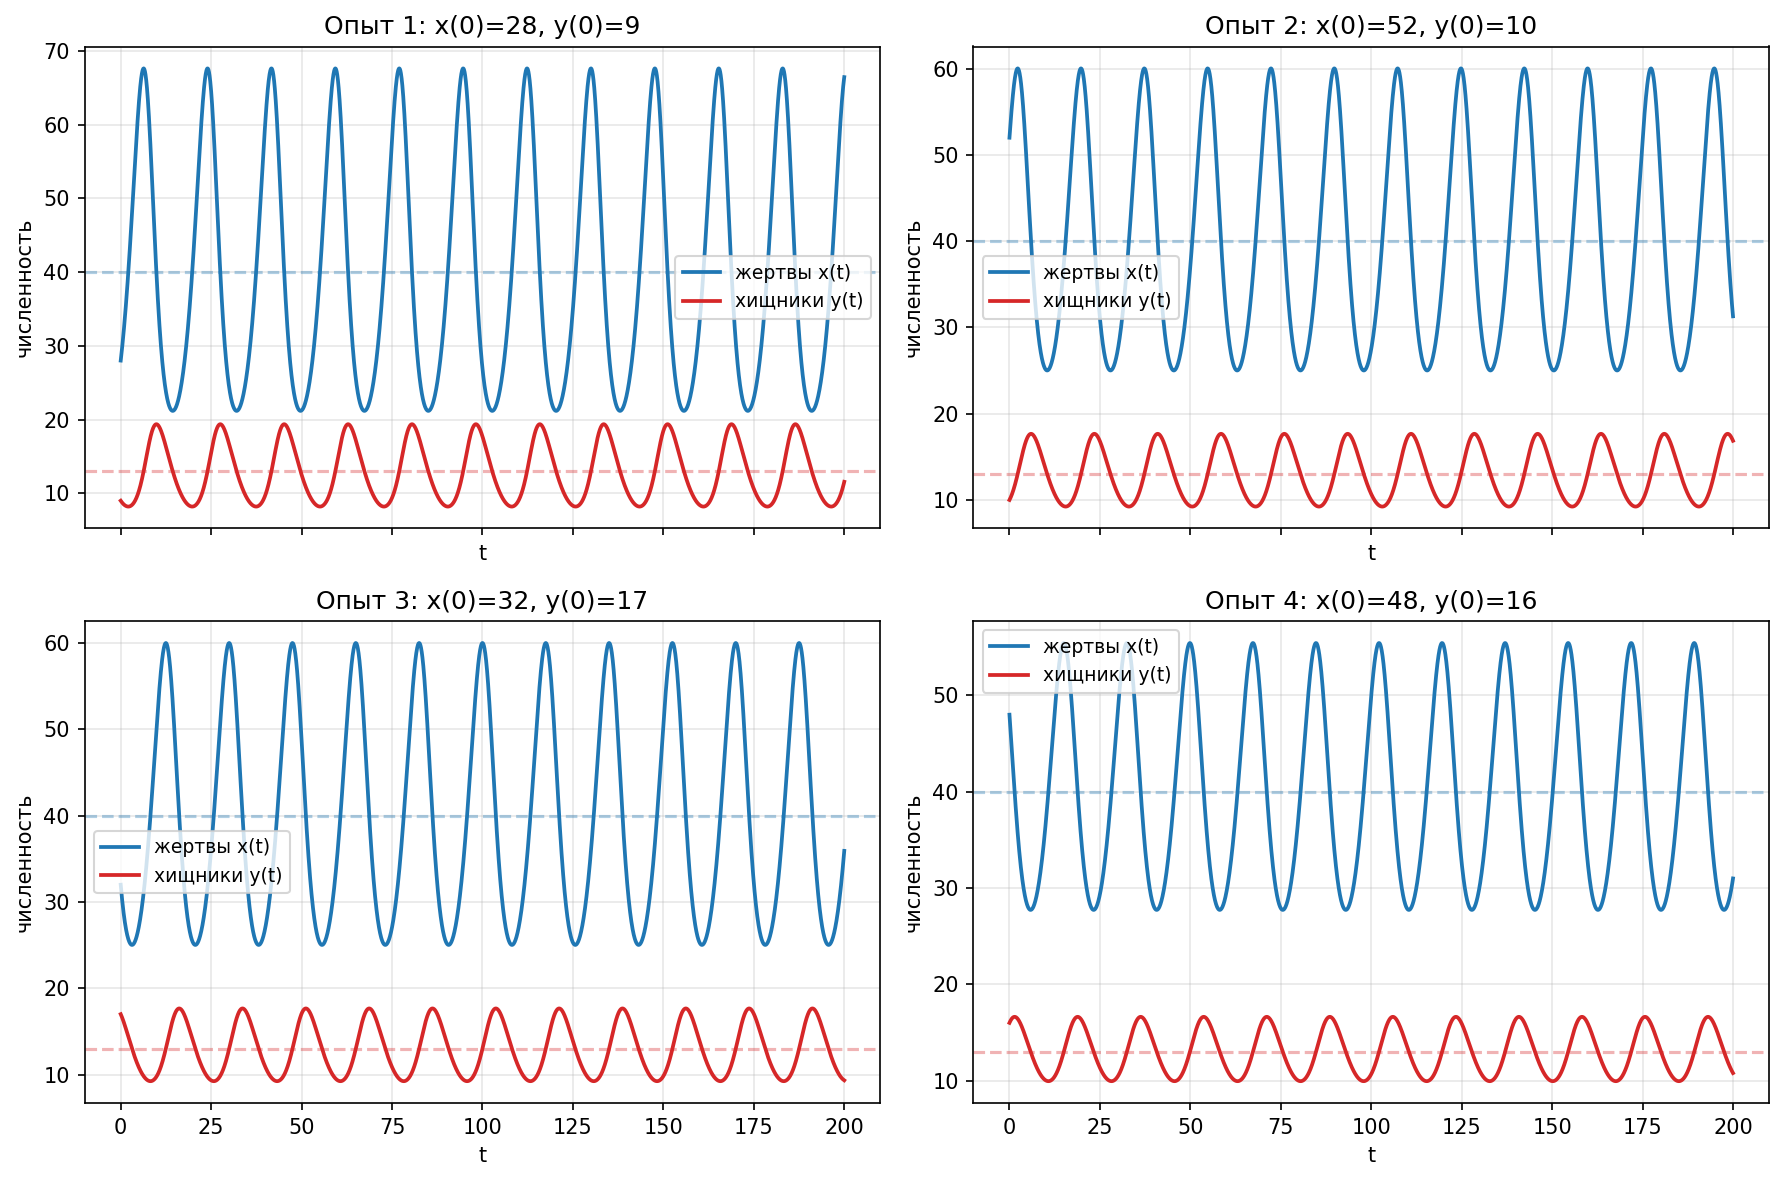

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for idx, (ax, sol, (x0, y0)) in enumerate(zip(axes, solutions, initial_conditions), start=1):
    ax.plot(sol.t, sol.y[0], label="жертвы x(t)", color="tab:blue", linewidth=1.8)
    ax.plot(sol.t, sol.y[1], label="хищники y(t)", color="tab:red", linewidth=1.8)
    ax.axhline(x_star, color="tab:blue", linestyle="--", alpha=0.35)
    ax.axhline(y_star, color="tab:red", linestyle="--", alpha=0.35)
    ax.set_title(f"Опыт {idx}: x(0)={x0}, y(0)={y0}")
    ax.set_xlabel("t")
    ax.set_ylabel("численность")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Фазовый портрет

Фазовый портрет показывает зависимость численности хищников от численности жертв. В отличие от временного графика, здесь не отображается само время, но хорошо видно геометрическое поведение системы. Для варианта 33 траектории обходят точку $E_*\approx(40;12.9984)$, что соответствует теоретическому выводу о центре.

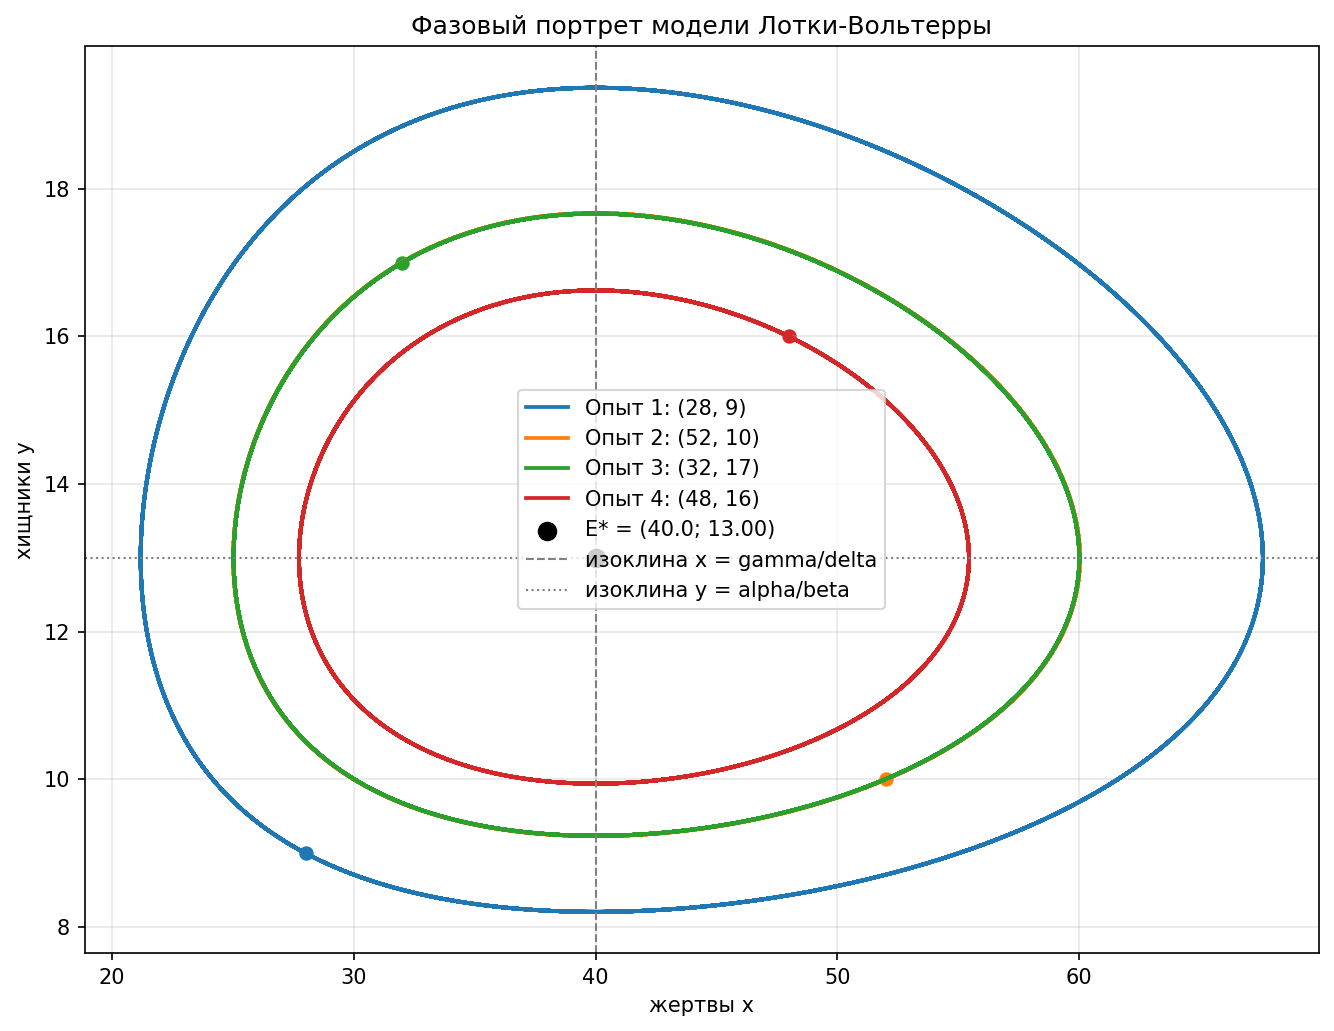

In [6]:
plt.figure(figsize=(9, 7))

for idx, (sol, (x0, y0)) in enumerate(zip(solutions, initial_conditions), start=1):
    plt.plot(sol.y[0], sol.y[1], linewidth=1.8, label=f"Опыт {idx}: ({x0}, {y0})")
    plt.scatter([x0], [y0], s=35)

plt.scatter([x_star], [y_star], color="black", s=70, zorder=5, label=f"E* = ({x_star:.1f}; {y_star:.2f})")
plt.axvline(x_star, color="gray", linestyle="--", linewidth=1, label="изоклина x = gamma/delta")
plt.axhline(y_star, color="gray", linestyle=":", linewidth=1, label="изоклина y = alpha/beta")
plt.xlabel("жертвы x")
plt.ylabel("хищники y")
plt.title("Фазовый портрет модели Лотки-Вольтерры")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Векторное поле

Поле направлений показывает, куда система движется из разных точек фазовой плоскости. В положительной области векторы согласуются с циклическим движением вокруг внутреннего равновесия.

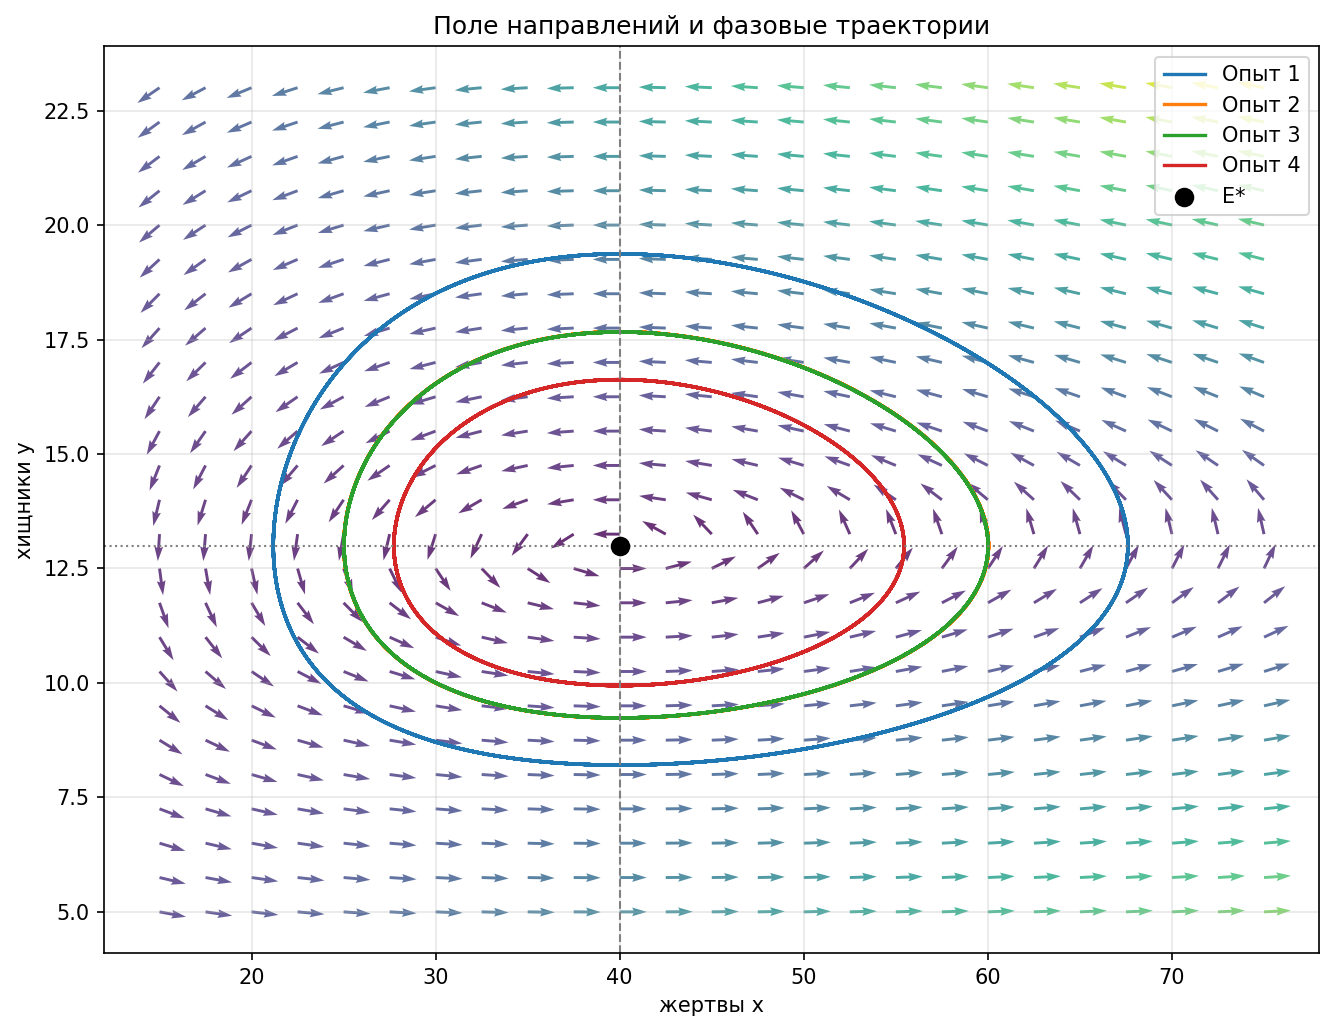

In [7]:
x_grid = np.linspace(15, 75, 25)
y_grid = np.linspace(5, 23, 25)
X, Y = np.meshgrid(x_grid, y_grid)
U = alpha * X - beta * X * Y
V = delta * X * Y - gamma * Y
speed = np.sqrt(U**2 + V**2)
U_norm = U / speed
V_norm = V / speed

plt.figure(figsize=(9, 7))
plt.quiver(X, Y, U_norm, V_norm, speed, cmap="viridis", alpha=0.8)
for idx, sol in enumerate(solutions, start=1):
    plt.plot(sol.y[0], sol.y[1], linewidth=1.6, label=f"Опыт {idx}")
plt.scatter([x_star], [y_star], color="black", s=70, zorder=5, label="E*")
plt.axvline(x_star, color="gray", linestyle="--", linewidth=1)
plt.axhline(y_star, color="gray", linestyle=":", linewidth=1)
plt.xlabel("жертвы x")
plt.ylabel("хищники y")
plt.title("Поле направлений и фазовые траектории")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Проверка первого интеграла

Так как классическая модель Лотки-Вольтерры имеет первый интеграл $H(x,y)$, значение этой функции вдоль одной фазовой траектории должно оставаться почти постоянным. В численном расчете возможны малые отклонения из-за конечной точности интегрирования.

In [8]:
print("Проверка постоянства H(x,y):")
for idx, (sol, (x0, y0)) in enumerate(zip(solutions, initial_conditions), start=1):
    H = first_integral(sol.y[0], sol.y[1])
    drift = H.max() - H.min()
    print(
        f"Опыт {idx}: H(0)={H[0]:.10f}, min(H)={H.min():.10f}, "
        f"max(H)={H.max():.10f}, размах={drift:.2e}"
    )

Проверка постоянства H(x,y):
Опыт 1: H(0)=-1.4465580361, min(H)=-1.4465580380, max(H)=-1.4465580358, размах=2.14e-09
Опыт 2: H(0)=-1.4655999145, min(H)=-1.4655999167, max(H)=-1.4655999144, размах=2.38e-09
Опыт 3: H(0)=-1.4656500190, min(H)=-1.4656500212, max(H)=-1.4656500190, размах=2.25e-09
Опыт 4: H(0)=-1.4751001581, min(H)=-1.4751001601, max(H)=-1.4751001581, размах=2.02e-09


## 10. Сравнение теоретических и численных результатов

Теоретически найденная точка равновесия равна:

$$
E_*=(40;12.9984).
$$

Численное решение системы уравнений $dx/dt=0$, $dy/dt=0$ дает то же значение с машинной точностью. Это подтверждает аналитический расчет.

Траектории, начатые не в точке равновесия, не приходят в $E_*$. Они совершают колебания вокруг нее. Это не является ошибкой: для классической модели Лотки-Вольтерры внутреннее равновесие является центром, а не асимптотически устойчивой точкой [3], [4]. Поэтому сравнение проводится не по последнему значению $x(t),y(t)$, а по структуре фазовых кривых и положению центра колебаний.

In [9]:
print("Сравнение равновесия и численных характеристик траекторий")
print(f"Теоретическое равновесие: x*={x_star:.4f}, y*={y_star:.4f}\n")
print("Опыт | x_min | x_max | y_min | y_max | mean_x(t>=100) | mean_y(t>=100)")
print("-" * 78)
for idx, sol in enumerate(solutions, start=1):
    x = sol.y[0]
    y = sol.y[1]
    mask = sol.t >= 100
    print(
        f"{idx:>4} | {x.min():>5.2f} | {x.max():>5.2f} | "
        f"{y.min():>5.2f} | {y.max():>5.2f} | "
        f"{x[mask].mean():>14.4f} | {y[mask].mean():>14.4f}"
    )

Сравнение равновесия и численных характеристик траекторий
Теоретическое равновесие: x*=40.0000, y*=12.9984

Опыт | x_min | x_max | y_min | y_max | mean_x(t>=100) | mean_y(t>=100)
------------------------------------------------------------------------------
   1 | 21.18 | 67.61 |  8.21 | 19.37 |        39.3724 |        12.7591
   2 | 25.01 | 60.03 |  9.23 | 17.67 |        40.6707 |        12.9646
   3 | 25.03 | 60.01 |  9.24 | 17.66 |        39.5125 |        13.1338
   4 | 27.73 | 55.45 |  9.94 | 16.62 |        40.0150 |        13.1242


## 11. Обсуждение результатов

Полученные графики соответствуют теоретическому анализу. Временные зависимости показывают регулярные колебания численности жертв и хищников. Фазовый портрет показывает замкнутые траектории вокруг точки $E_*$. Это согласуется с классификацией внутреннего равновесия как центра [3], [4].

Различия между теоретическими и численными результатами связаны с конечной точностью численного интегрирования и с тем, что расчет ведется на конечном интервале времени. Поэтому первый интеграл сохраняется не абсолютно, а с очень малой погрешностью, а средние значения на выбранном интервале могут немного отличаться от координат равновесия.

Начальные условия влияют на амплитуду колебаний. Чем дальше начальная точка расположена от $E_*$ на фазовой плоскости, тем шире соответствующая замкнутая траектория. При этом сама точка равновесия определяется только параметрами $\alpha$, $\beta$, $\delta$, $\gamma$, а не начальными условиями.

Классическая модель является идеализацией: она строится на упрощенных предположениях о взаимодействии двух популяций [3], [4]. В реальных экосистемах могут быть ограниченность ресурсов, сезонность, случайные воздействия среды и другие факторы. Тем не менее базовая система Лотки-Вольтерры остается удобной отправной точкой для анализа взаимодействующих популяций.

## Заключение

В работе была рассмотрена классическая модель Лотки-Вольтерры для описания взаимодействия популяций жертв и хищников. Для варианта 33 использованы параметры $\alpha=0.489$, $\beta=0.03762$, $\delta=0.00675$, $\gamma=0.27$ и четыре набора начальных условий.

Аналитически найдены две точки равновесия: $E_0=(0,0)$ и $E_*\approx(40;12.9984)$. Анализ матрицы Якоби показал, что начало координат является седлом, а положительная стационарная точка является центром. Численное моделирование подтвердило эти выводы: фазовые траектории являются замкнутыми кривыми вокруг точки $E_*$, а временные графики демонстрируют периодические колебания популяций.

Таким образом, теоретические расчеты и вычислительный эксперимент согласуются между собой. Модель показывает, что взаимодействие хищник-жертва может порождать циклические изменения численности даже при постоянных параметрах среды.

## Список использованной литературы

1. Lotka A. J. Elements of Physical Biology. — Baltimore : Williams & Wilkins Company, 1925. — 460 p. — URL открытого текста: https://archive.org/stream/elementsofphysic0000alfr/elementsofphysic0000alfr_djvu.txt
2. Volterra V. Variations and fluctuations of the number of individuals in animal species living together // Nature. — 1926. — Vol. 118. — P. 558–560. — Открытая копия текста: https://jxshix.people.wm.edu/2009-harbin-course/classic/Volterra-1928.pdf
3. Lotka–Volterra equations // Scholarpedia. — URL: http://www.scholarpedia.org/article/Predator-prey_model (раздел «Lotka-Volterra Model», дата обращения: 03.05.2026).
4. Lotka–Volterra equations // Wikipedia. — URL: https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations (дата обращения: 03.05.2026).

[^lotka]: Открытый текст книги Лотки на Internet Archive: https://archive.org/stream/elementsofphysic0000alfr/elementsofphysic0000alfr_djvu.txt
[^volterra]: Открытая копия текста Вольтерры: https://jxshix.people.wm.edu/2009-harbin-course/classic/Volterra-1928.pdf
[^scholarpedia]: Страница Scholarpedia по модели хищник-жертва: http://www.scholarpedia.org/article/Predator-prey_model
[^wiki]: Страница Wikipedia по уравнениям Лотки-Вольтерры: https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations